In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

from mot_helper import *

# Notation

$\boldsymbol{w}_i$ and ${r_i}$ are the points and weights for the first density

$\boldsymbol{v}_j$ and ${c_j}$ are the points and weights for the second density

V = $[\boldsymbol{v}_1, ..., \boldsymbol{v}_n]$

W = $[r_1\boldsymbol{w}_1, ..., r_n\boldsymbol{w}_n]$

PV = W

C is Cost Matrix

# Execution

In [6]:
# 1. Generate Synthetic Data (Black-Scholes Lognormal Distributions)
S0 = 100.0
RISK_FREE_RATE = 0.05
vol = 0.20 # 20% volatility
T1 = 1.0 # 1 Year maturity
T2 = 2.0 # 2 Year maturity

n = 400

mu1 = (RISK_FREE_RATE - 0.5 * vol**2) * T1
std1 = vol * np.sqrt(T1)

mu2 = (RISK_FREE_RATE - 0.5 * vol**2) * T2
std2 = vol * np.sqrt(T2)

X1 = np.linspace(mu1 - 4 * std1, mu1 + 4 * std1, n)
X2 = np.linspace(mu2 - 4 * std2, mu2 + 4 * std2, n)

r_mass = norm.pdf(X1, mu1, std1)
r_mass /= np.sum(r_mass)

c_mass = norm.pdf(X2, mu2, std2)
c_mass /= np.sum(c_mass)

# 2. MOT variables
d = 1

r = r_mass
c = c_mass

V = np.exp(X2).reshape(n, 1)

expected_expX2_given_X1 = np.exp(X1) * np.exp(RISK_FREE_RATE * (T2 - T1))
W = (r * expected_expX2_given_X1).reshape(n, 1)

# 3. Cost MAtrices
dt = T2 - T1

base_sq_dist = (X2[None, :] - X1[:, None])**2

# --- Matrix 1: Minimize Path Volatility ---
C_min_vol = base_sq_dist

# --- Matrix 2: Maximize Path Volatility ---
C_max_vol = -base_sq_dist

# --- Matrix 3: Target Volatility (Martingale Schrodinger Bridge) ---
target_sigma = 0.25

C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)

# 4. MOT Algorithm
# Select the desired regime here:
selected_C = C_max_vol 

regime_eta = 1.0 if selected_C is C_target_vol else 100.0

P_opt, dual_vars, history = sparse_newton_MOT(
    C=selected_C, 
    r=r, 
    c=c, 
    V=V, 
    W=W, 
    N1=5,          
    N2=100,         
    keep_frac=0.1,  
    eps=0.01,
    eta=regime_eta
)

print(f"--- Optimization Results ---")
print(f"Algorithm run with eta = {regime_eta}")
print(f"Optimal Transport Plan P shape: {P_opt.shape}\n")

# --- Path Volatility Calculation ---
expected_quadratic_variation = np.sum(P_opt * base_sq_dist)

realized_path_vol = np.sqrt(expected_quadratic_variation / dt)

print(f"--- Volatility Metrics ---")
print(f"Expected Quadratic Variation: {expected_quadratic_variation:.6f}")
print(f"Realized Annualized Path Volatility: {realized_path_vol:.2%}\n")

# --- Constraint Checks ---
print(f"--- Constraint Diagnostics ---")
PV = P_opt @ V
print(f"Max martingale constraint violation |PV - W|: {np.max(np.abs(PV - W)):.6e}")

print(f"Row marginal violation: {np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten())):.6e}")
print(f"Col marginal violation: {np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten())):.6e}")

Line search failed at outer 0, inner 0; stopping.
--- Optimization Results ---
Algorithm run with eta = 100.0
Optimal Transport Plan P shape: (400, 400)

--- Volatility Metrics ---
Expected Quadratic Variation: 0.059782
Realized Annualized Path Volatility: 24.45%

--- Constraint Diagnostics ---
Max martingale constraint violation |PV - W|: 1.976213e-04
Row marginal violation: 4.246911e-07
Col marginal violation: 4.823372e-07


Starting Eta Sweep Analysis...

--- Processing MIN Volatility Regime ---


<>:69: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:69: SyntaxWarning: invalid escape sequence '\e'
<>:70: SyntaxWarning: invalid escape sequence '\e'
<>:78: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_83400/2429732181.py:69: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_title('Realized Path Volatility vs. $\eta$')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_83400/2429732181.py:70: SyntaxWarning: invalid escape sequence '\e'
  axes[0].set_xlabel('Entropic Regularization ($\eta$)')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_83400/2429732181.py:78: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_title('Max Martingale Violation vs. $\eta$')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtd

Eta:   1.0 | Vol: 22.11% | Martingale Viol: 5.71e-05 | Marg Viol: 4.30e-06
Eta:   5.0 | Vol: 21.64% | Martingale Viol: 4.11e-05 | Marg Viol: 1.94e-06
Eta:  10.0 | Vol: 20.73% | Martingale Viol: 1.50e-05 | Marg Viol: 4.74e-07
Eta:  25.0 | Vol: 18.59% | Martingale Viol: 5.75e-05 | Marg Viol: 3.24e-06
Eta:  50.0 | Vol: 17.82% | Martingale Viol: 1.16e-04 | Marg Viol: 1.76e-05
Eta:  75.0 | Vol: 17.40% | Martingale Viol: 1.51e-04 | Marg Viol: 2.86e-05
Eta: 100.0 | Vol: 17.13% | Martingale Viol: 1.75e-04 | Marg Viol: 3.42e-05

--- Processing MAX Volatility Regime ---
Eta:   1.0 | Vol: 22.27% | Martingale Viol: 6.37e-05 | Marg Viol: 5.74e-06
Line search failed at outer 0, inner 0; stopping.
Eta:   5.0 | Vol: 22.50% | Martingale Viol: 7.46e-05 | Marg Viol: 8.86e-06
Line search failed at outer 0, inner 0; stopping.
Eta:  10.0 | Vol: 22.74% | Martingale Viol: 8.46e-05 | Marg Viol: 1.13e-05
Line search failed at outer 0, inner 0; stopping.
Eta:  25.0 | Vol: 23.37% | Martingale Viol: 9.81e-05 | Mar

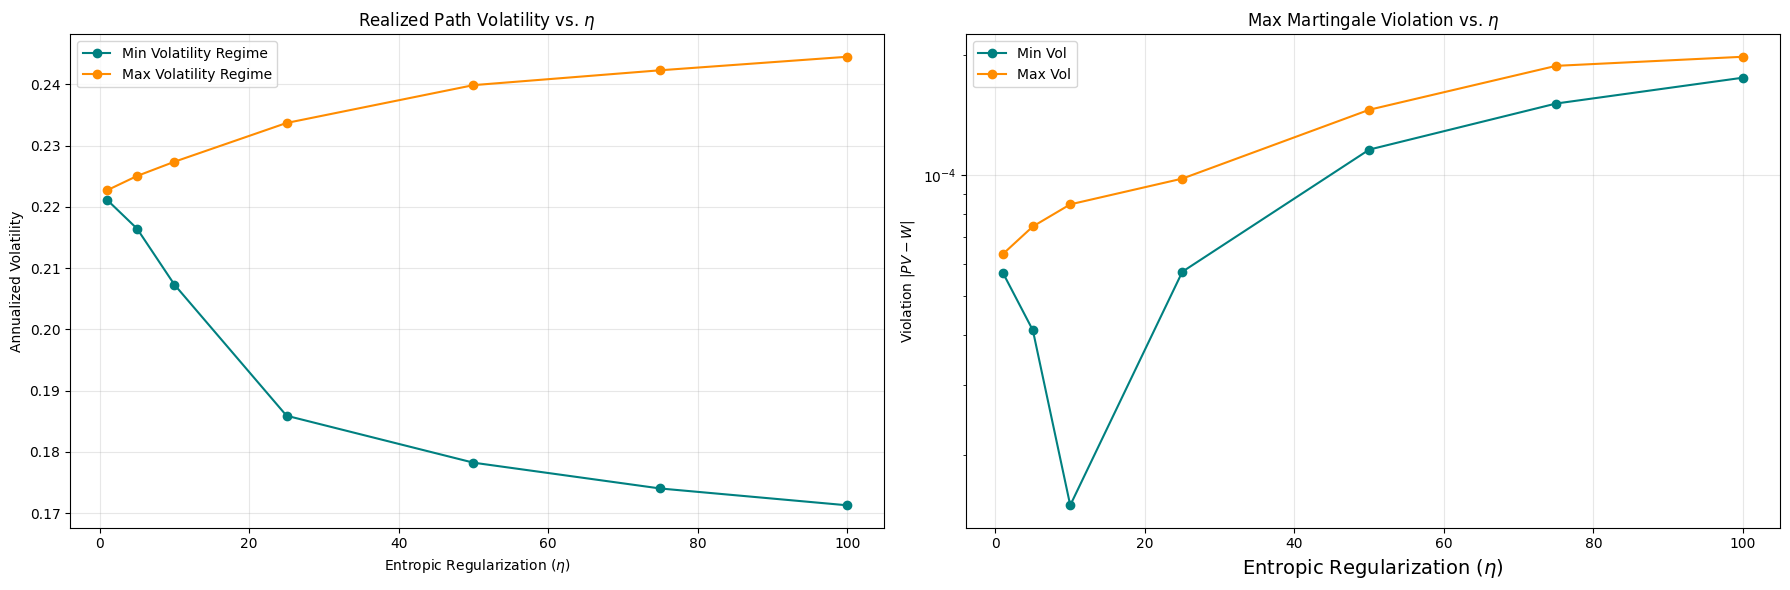

In [3]:
# =====================================================================
# Min / Max Cost Analysis
# ===================================================================== 
eta_values = [1.0, 5.0, 10.0, 25.0, 50.0, 75.0, 100.0]

metrics = {
    'min': {'vol': [], 'mart_viol': [], 'marg_viol': []},
    'max': {'vol': [], 'mart_viol': [], 'marg_viol': []}
}

regimes = {
    'min': C_min_vol,
    'max': C_max_vol
}

print("Starting Eta Sweep Analysis...")
all_couplings = {'min': [], 'max': []}

for regime_name, C_matrix in regimes.items():
    print(f"\n--- Processing {regime_name.upper()} Volatility Regime ---")
    
    for current_eta in eta_values:        
        P_opt, dual_vars, history = sparse_newton_MOT(
            C=C_matrix, 
            r=r, 
            c=c, 
            V=V, 
            W=W, 
            N1=5,
            N2=100,         
            keep_frac=0.1,  
            eps=0.01,
            eta=current_eta
        )
        
        # 1. Path Volatility Calculation
        expected_quadratic_variation = np.sum(P_opt * base_sq_dist)
        realized_path_vol = np.sqrt(expected_quadratic_variation / dt)
        
        # 2. Constraint Violations
        PV = P_opt @ V
        mart_viol = np.max(np.abs(PV - W))
        
        row_viol = np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten()))
        col_viol = np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten()))
        max_marg_viol = max(row_viol, col_viol)
        
        metrics[regime_name]['vol'].append(realized_path_vol)
        metrics[regime_name]['mart_viol'].append(mart_viol)
        metrics[regime_name]['marg_viol'].append(max_marg_viol)
        
        print(f"Eta: {current_eta:>5.1f} | Vol: {realized_path_vol:>6.2%} | Martingale Viol: {mart_viol:.2e} | Marg Viol: {max_marg_viol:.2e}")
        all_couplings[regime_name].append(P_opt.copy())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Realized Volatility vs Eta
axes[0].plot(eta_values, metrics['min']['vol'], marker='o', color='teal', label='Min Volatility Regime')
axes[0].plot(eta_values, metrics['max']['vol'], marker='o', color='darkorange', label='Max Volatility Regime')
axes[0].set_title('Realized Path Volatility vs. $\eta$')
axes[0].set_xlabel('Entropic Regularization ($\eta$)')
axes[0].set_ylabel('Annualized Volatility')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Martingale Violation vs Eta
axes[1].plot(eta_values, metrics['min']['mart_viol'], marker='o', color='teal', label='Min Vol')
axes[1].plot(eta_values, metrics['max']['mart_viol'], marker='o', color='darkorange', label='Max Vol')
axes[1].set_title('Max Martingale Violation vs. $\eta$')
axes[1].set_xlabel('Entropic Regularization ($\eta$)', fontsize=14)
axes[1].set_ylabel('Violation $|PV - W|$')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<>:40: SyntaxWarning: invalid escape sequence '\e'
<>:40: SyntaxWarning: invalid escape sequence '\e'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/2639612937.py:40: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$\eta = {eta}$", fontsize=14)


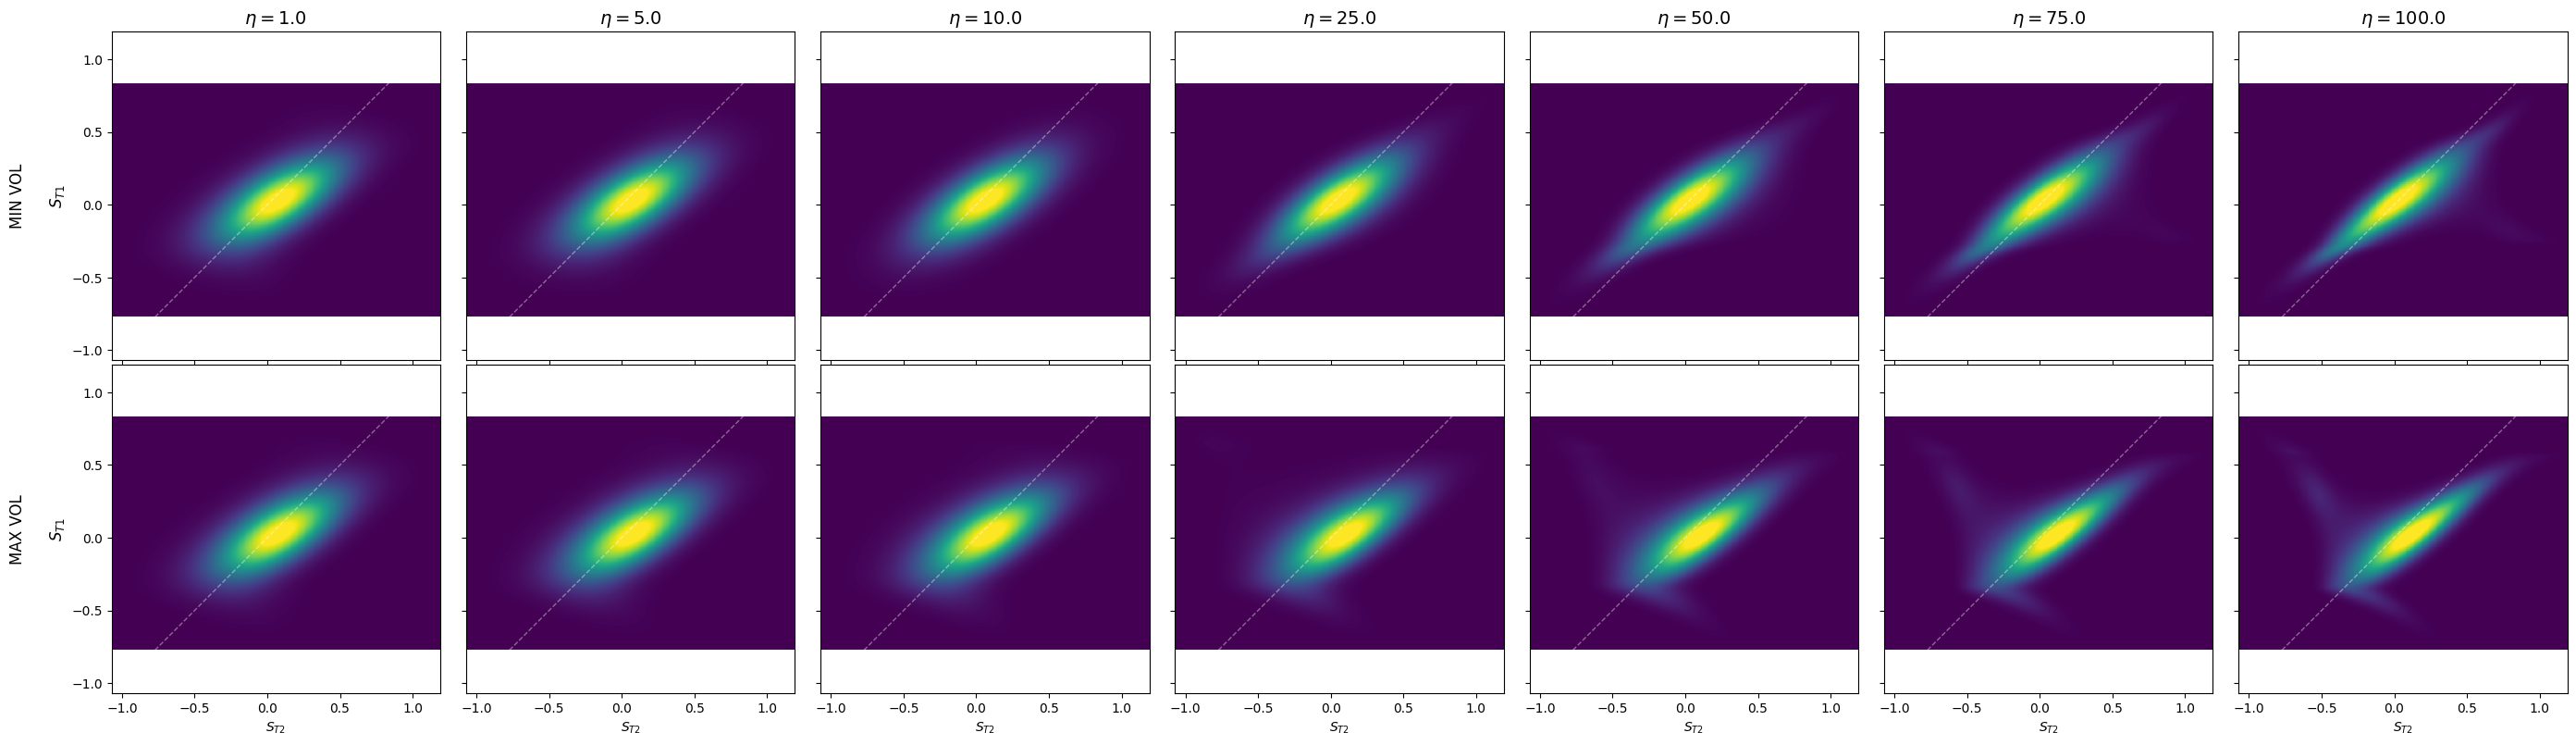

In [195]:
def visualize_coupling_grid(all_couplings, eta_values, K1, K2):
    """
    Visualizes a grid of coupling matrices.
    all_couplings: dict {regime: [list of P matrices]}
    """
    n_regimes = len(all_couplings)
    n_etas = len(eta_values)
    
    price_min = min(np.min(K1), np.min(K2))
    price_max = max(np.max(K1), np.max(K2))
    
    fig, axes = plt.subplots(n_regimes, n_etas, figsize=(4 * n_etas, 4 * n_regimes), 
                             sharex=True, sharey=True)
    
    regime_names = list(all_couplings.keys())
    
    for i, regime in enumerate(regime_names):
        couplings = all_couplings[regime]
        
        for j, eta in enumerate(eta_values):
            ax = axes[i, j]
            P = couplings[j]
            
            # Use 99.5 percentile for color scaling to avoid outliers washing out the plot
            vmax = np.percentile(P, 99.5)
            
            # Plot the heatmap
            im = ax.pcolormesh(K2, K1, P, cmap='viridis', shading='auto', vmax=vmax)
            
            # Add Martingale diagonal for reference
            ax.plot([price_min, price_max], [price_min, price_max], 
                    color='white', linestyle='--', alpha=0.4, lw=1)
            
            # Formatting
            if i == 0:
                ax.set_title(f"$\eta = {eta}$", fontsize=14)
            if j == 0:
                ax.set_ylabel(f"{regime.upper()} VOL\n\n$S_{{T1}}$", fontsize=12)
            if i == n_regimes - 1:
                ax.set_xlabel("$S_{{T2}}$")
                
            ax.set_xlim(price_min, price_max)
            ax.set_ylim(price_min, price_max)
            ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

# 3. Call the grid visualization
visualize_coupling_grid(all_couplings, eta_values, X1, X2)

<>:68: SyntaxWarning: invalid escape sequence '\e'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:91: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\e'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:91: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/335730007.py:68: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\eta$ = {current_eta}'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/335730007.py:75: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_xlabel('Target Prior Volatility ($\sigma_0$)')
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/335730007.py:87: SyntaxWarning: invalid escape sequence '\e'
  label=f'$\eta$ = {current_eta}'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/335730007.py:91: Syn

Starting Target Volatility & Eta Sweep...

--- Processing Eta = 1.0 ---
Target Vol:  5.00% | Realized Vol: 16.63% | Violations (Mart/Marg): 3.1e-04 / 1.0e-04
Target Vol:  9.44% | Realized Vol: 17.72% | Violations (Mart/Marg): 1.2e-04 / 1.8e-05
Target Vol: 13.89% | Realized Vol: 18.54% | Violations (Mart/Marg): 6.0e-05 / 2.6e-06
Target Vol: 18.33% | Realized Vol: 19.77% | Violations (Mart/Marg): 1.4e-05 / 5.9e-08
Line search failed at outer 17, inner 0; stopping.
Target Vol: 22.78% | Realized Vol: 20.80% | Violations (Mart/Marg): 1.7e-05 / 3.4e-07
Line search failed at outer 16, inner 0; stopping.
Line search failed at outer 18, inner 0; stopping.
Target Vol: 27.22% | Realized Vol: 21.36% | Violations (Mart/Marg): 3.3e-05 / 1.0e-06
Line search failed at outer 19, inner 0; stopping.
Target Vol: 31.67% | Realized Vol: 21.64% | Violations (Mart/Marg): 4.1e-05 / 1.3e-06
Target Vol: 36.11% | Realized Vol: 21.80% | Violations (Mart/Marg): 4.6e-05 / 1.7e-06
Line search failed at outer 19, inne

/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/935487640.py:46: RuntimeWarning: divide by zero encountered in log
  y_new = y + (np.log(c) - np.log(col_sums))/eta
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/935487640.py:482: MatrixRankWarning: Matrix is exactly singular
  delta = spsolve(H_damped, -grad_vec)


Target Vol:  9.44% | Realized Vol: 22.87% | Violations (Mart/Marg): 4.0e-02 / 1.9e-02
Target Vol: 13.89% | Realized Vol: 15.78% | Violations (Mart/Marg): 8.4e-04 / 2.8e-04
Target Vol: 18.33% | Realized Vol: 15.86% | Violations (Mart/Marg): 4.8e-04 / 1.6e-04
Target Vol: 22.78% | Realized Vol: 15.73% | Violations (Mart/Marg): 2.7e-04 / 1.0e-04
Target Vol: 27.22% | Realized Vol: 15.89% | Violations (Mart/Marg): 2.6e-04 / 8.5e-05
Target Vol: 31.67% | Realized Vol: 16.34% | Violations (Mart/Marg): 2.7e-04 / 9.8e-05
Target Vol: 36.11% | Realized Vol: 16.67% | Violations (Mart/Marg): 2.4e-04 / 8.0e-05
Target Vol: 40.56% | Realized Vol: 16.82% | Violations (Mart/Marg): 2.1e-04 / 4.0e-05
Target Vol: 45.00% | Realized Vol: 16.96% | Violations (Mart/Marg): 1.9e-04 / 3.7e-05

--- Processing Eta = 75.0 ---
Line search failed at outer 0, inner 0; stopping.
Non-finite P in history block; stopping.
Solver returned NaN at iter 20. Stopping Newton phase.
Target Vol:  5.00% | Realized Vol:   inf% | Viola

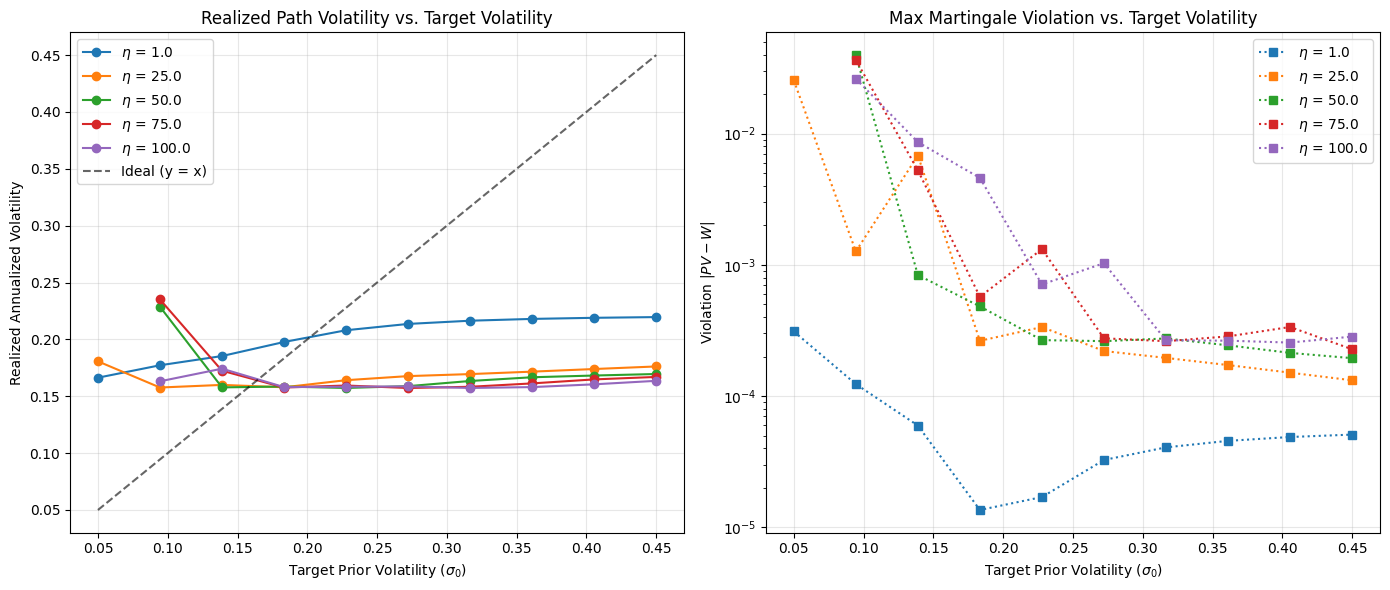

In [193]:
# =====================================================================
# Target Vol Analysis
# =====================================================================
eta_values = [1.0, 25.0, 50.0, 75.0, 100.0]
target_sigmas = np.linspace(0.05, 0.45, 10)

results = {eta: {'realized_vol': [], 'mart_viol': [], 'marg_viol': []} for eta in eta_values}

print("Starting Target Volatility & Eta Sweep...")

for current_eta in eta_values:
    print(f"\n--- Processing Eta = {current_eta} ---")
    
    for target_sigma in target_sigmas:
        C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)
        
        P_opt, dual_vars, history = sparse_newton_MOT(
            C=C_target_vol, 
            r=r, 
            c=c, 
            V=V, 
            W=W, 
            N1=20,          
            N2=100,         
            keep_frac=0.1,  
            eps=0.01,
            eta=current_eta
        )
        
        # 1. Path Volatility Calculation
        expected_quadratic_variation = np.sum(P_opt * base_sq_dist)
        realized_path_vol = np.sqrt(expected_quadratic_variation / dt)
        
        # 2. Constraint Violations
        PV = P_opt @ V
        mart_viol = np.max(np.abs(PV - W))
        
        row_viol = np.max(np.abs(np.sum(P_opt, axis=1) - r.flatten()))
        col_viol = np.max(np.abs(np.sum(P_opt, axis=0) - c.flatten()))
        max_marg_viol = max(row_viol, col_viol)
        
        results[current_eta]['realized_vol'].append(realized_path_vol)
        results[current_eta]['mart_viol'].append(mart_viol)
        results[current_eta]['marg_viol'].append(max_marg_viol)
        
        print(f"Target Vol: {target_sigma:>6.2%} | Realized Vol: {realized_path_vol:>6.2%} | Violations (Mart/Marg): {mart_viol:.1e} / {max_marg_viol:.1e}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Target Volatility vs. Realized Volatility for different Etas
for current_eta in eta_values:
    axes[0].plot(
        target_sigmas, 
        results[current_eta]['realized_vol'], 
        marker='o', 
        label=f'$\eta$ = {current_eta}'
    )

axes[0].plot(target_sigmas, target_sigmas, 'k--', alpha=0.6, label='Ideal (y = x)')

axes[0].set_title('Realized Path Volatility vs. Target Volatility')
axes[0].set_xlabel('Target Prior Volatility ($\sigma_0$)')
axes[0].set_ylabel('Realized Annualized Volatility')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Martingale Violations vs. Target Volatility
for current_eta in eta_values:
    axes[1].plot(
        target_sigmas, 
        results[current_eta]['mart_viol'], 
        marker='s', 
        linestyle=':',
        label=f'$\eta$ = {current_eta}'
    )

axes[1].set_title('Max Martingale Violation vs. Target Volatility')
axes[1].set_xlabel('Target Prior Volatility ($\sigma_0$)')
axes[1].set_ylabel('Violation $|PV - W|$')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hv/bm8vcdrx7_dfrqhgzvtdvdbc0000gn/T/ipykernel_16885/65236533.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Target $\sigma$: {sigma:.1%}")


Starting Volatility Sweep for fixed Eta = 1.0...
Line search failed at outer 17, inner 0; stopping.
Line search failed at outer 16, inner 0; stopping.
Line search failed at outer 18, inner 0; stopping.
Line search failed at outer 19, inner 0; stopping.
Line search failed at outer 19, inner 0; stopping.


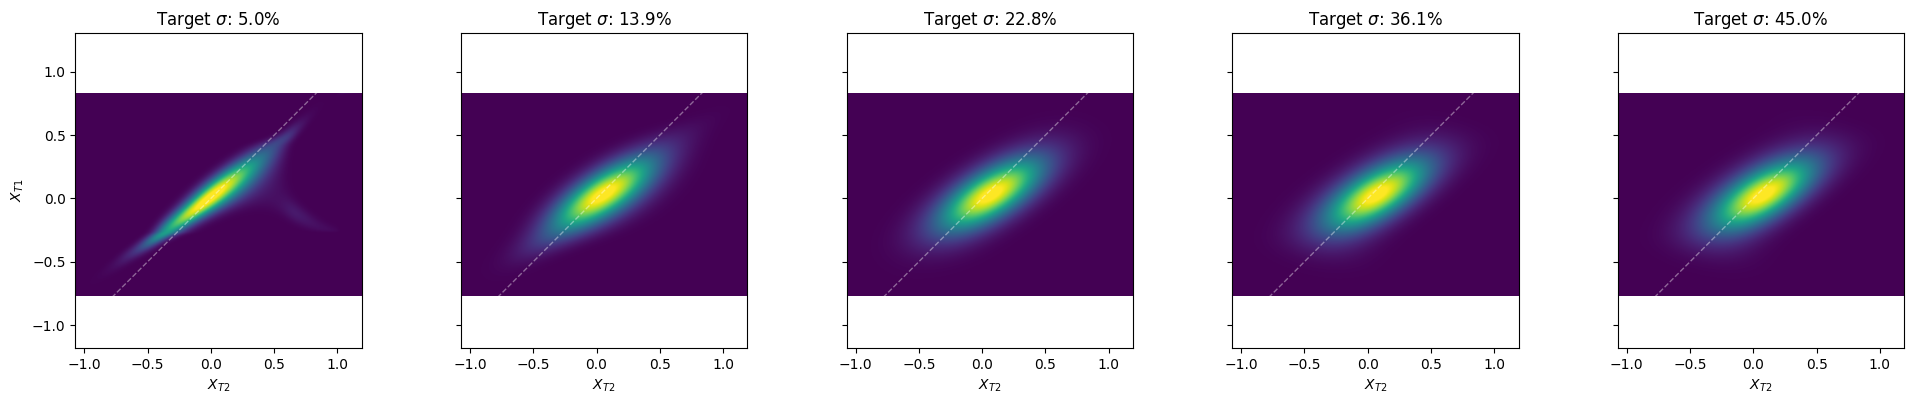

In [197]:
import numpy as np
import matplotlib.pyplot as plt

def plot_volatility_evolution(vol_couplings, target_sigmas, K1, K2):
    """
    Plots a row of coupling matrices for increasing target volatilities.
    """
    n_plots = len(vol_couplings)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    
    price_min = min(K1.min(), K2.min())
    price_max = max(K1.max(), K2.max())

    for i, (sigma, P) in enumerate(zip(target_sigmas, vol_couplings)):
        ax = axes[i]
        
        # Use a consistent percentile for the color scale to allow comparison
        vmax = np.percentile(P, 99.7)
        
        # Plot heatmap
        im = ax.imshow(
            P, 
            origin='lower', 
            extent=[K2.min(), K2.max(), K1.min(), K1.max()],
            cmap='viridis', 
            vmax=vmax,
            aspect='equal'
        )
        
        # Reference diagonal
        ax.plot([price_min, price_max], [price_min, price_max], 
                color='white', linestyle='--', alpha=0.4, lw=1)
        
        ax.set_title(f"Target $\sigma$: {sigma:.1%}")
        ax.set_xlabel("$X_{T2}$")
        if i == 0:
            ax.set_ylabel("$X_{T1}$")

    plt.tight_layout()
    plt.show()

# =====================================================================
# Integrated Analysis Loop
# =====================================================================

fixed_eta = 1.0
# We pick a subset of sigmas to plot so the grid isn't too crowded (e.g., every 2nd or 3rd)
plot_indices = [0, 2, 4, 7, 9] 
couplings_to_plot = []
sigmas_to_plot = []

print(f"Starting Volatility Sweep for fixed Eta = {fixed_eta}...")

for i, target_sigma in enumerate(target_sigmas):
    C_target_vol = base_sq_dist / (2 * (target_sigma**2) * dt)
    
    P_opt, _, _ = sparse_newton_MOT(
        C=C_target_vol, 
        r=r, c=c, V=V, W=W, 
        N1=20, N2=100, 
        keep_frac=0.1, eps=0.01,
        eta=fixed_eta
    )
    
    # Only store the ones we want to visualize
    if i in plot_indices:
        couplings_to_plot.append(P_opt.copy())
        sigmas_to_plot.append(target_sigma)
    
    # ... (Keep your metrics storage code here if needed) ...

# Final Plot
plot_volatility_evolution(couplings_to_plot, sigmas_to_plot, X1, X2)

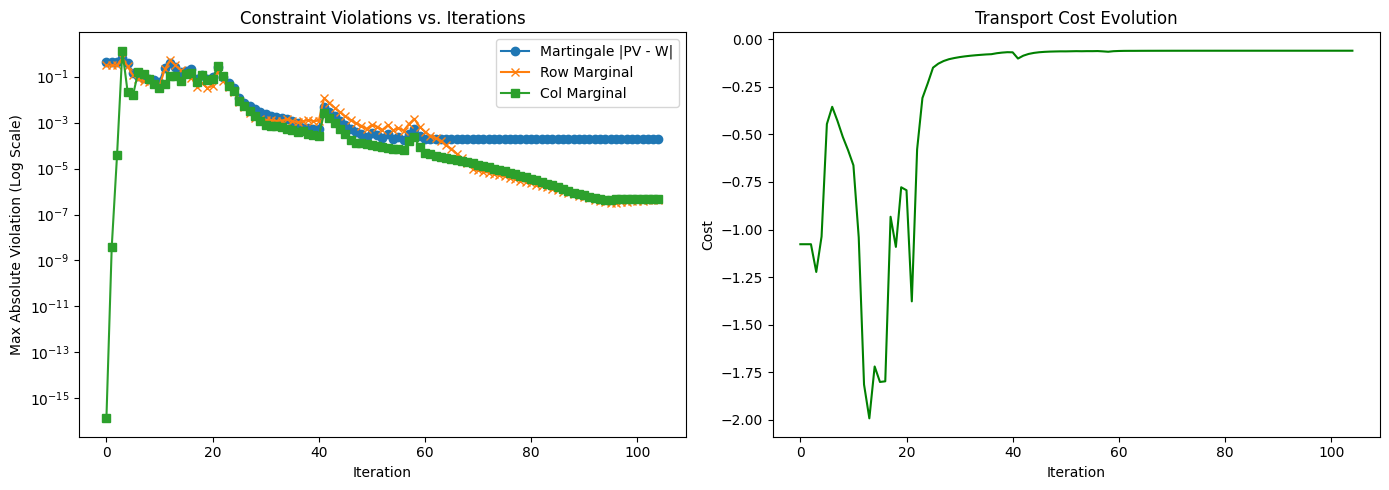

In [188]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# 1. Constraint Violations over Iterations (Log Scale)
axs[0].plot(history['iteration'], history['martingale_violation'], label='Martingale |PV - W|', marker='o')
axs[0].plot(history['iteration'], history['row_violation'], label='Row Marginal', marker='x')
axs[0].plot(history['iteration'], history['col_violation'], label='Col Marginal', marker='s')
axs[0].set_yscale('log')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('Max Absolute Violation (Log Scale)')
axs[0].set_title('Constraint Violations vs. Iterations')
axs[0].legend()

# 3. Objective Function (Transport Cost)
axs[1].plot(history['iteration'], history['transport_cost'], color='green')
#axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Cost')
axs[1].set_title('Transport Cost Evolution')

plt.tight_layout()
plt.show()


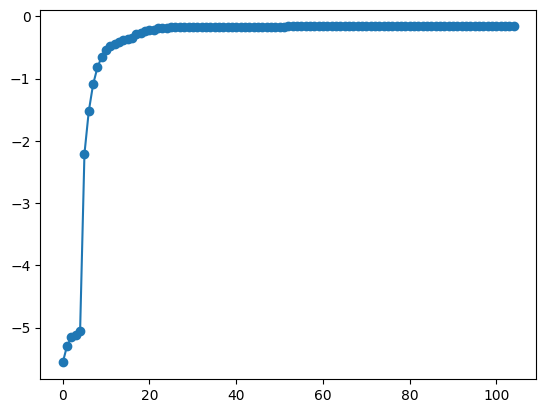

In [189]:
plt.plot(history['iteration'], history['dual'], label='Martingale |PV - W|', marker='o')